In [2]:
import pandas as pd
import numpy as np

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, classification_report

In [3]:
 df=pd.read_csv("C:\\Users\\New folder\\rss.csv")

In [4]:
df.info()
df.describe()
df.isnull().sum()
df.columns

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 21 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customerID        7043 non-null   object 
 1   gender            7043 non-null   object 
 2   SeniorCitizen     7043 non-null   int64  
 3   Partner           7043 non-null   object 
 4   Dependents        7043 non-null   object 
 5   tenure            7043 non-null   int64  
 6   PhoneService      7043 non-null   object 
 7   MultipleLines     7043 non-null   object 
 8   InternetService   7043 non-null   object 
 9   OnlineSecurity    7043 non-null   object 
 10  OnlineBackup      7043 non-null   object 
 11  DeviceProtection  7043 non-null   object 
 12  TechSupport       7043 non-null   object 
 13  StreamingTV       7043 non-null   object 
 14  StreamingMovies   7043 non-null   object 
 15  Contract          7043 non-null   object 
 16  PaperlessBilling  7043 non-null   object 


Index(['customerID', 'gender', 'SeniorCitizen', 'Partner', 'Dependents',
       'tenure', 'PhoneService', 'MultipleLines', 'InternetService',
       'OnlineSecurity', 'OnlineBackup', 'DeviceProtection', 'TechSupport',
       'StreamingTV', 'StreamingMovies', 'Contract', 'PaperlessBilling',
       'PaymentMethod', 'MonthlyCharges', 'TotalCharges', 'Churn'],
      dtype='object')

In [5]:
from imblearn.over_sampling import RandomOverSampler

X = df.drop(["customerID", "Churn"], axis=1)
y = df["Churn"]



In [6]:
ros = RandomOverSampler(random_state=42)
X,y = ros.fit_resample(X,y)


In [7]:
X.value_counts()

gender  SeniorCitizen  Partner  Dependents  tenure  PhoneService  MultipleLines     InternetService  OnlineSecurity       OnlineBackup         DeviceProtection     TechSupport          StreamingTV          StreamingMovies      Contract        PaperlessBilling  PaymentMethod              MonthlyCharges  TotalCharges
Male    0              No       No          1       Yes           No                Fiber optic      No                   No                   No                   No                   No                   No                   Month-to-month  Yes               Electronic check           69.35           69.35           9
Female  0              Yes      No          20      No            No phone service  DSL              No                   No                   No                   No                   No                   No                   Month-to-month  Yes               Electronic check           24.45           482.8           9
                       No       No     

In [8]:
from sklearn.preprocessing import OrdinalEncoder
encoder = OrdinalEncoder()
X_encoded = encoder.fit_transform(X)

In [9]:
X_train, X_test, y_train, y_test = train_test_split(X_encoded, y, test_size=0.2, random_state=42)

In [12]:
scaler=StandardScaler()
X_train=scaler.fit_transform(X_train)
X_test=scaler.transform(X_test)

In [13]:
model=LogisticRegression()
model.fit(X_train,y_train)

,penalty,'l2'
,dual,False
,tol,0.0001
,C,1.0
,fit_intercept,True
,intercept_scaling,1
,class_weight,None
,random_state,None
,solver,'lbfgs'
,max_iter,100
,multi_class,'deprecated'


In [14]:
y_pred=model.predict(X_test)

In [15]:
print("classification report:\n", classification_report(y_test, y_pred))
print("accuracy score:", accuracy_score(y_test, y_pred))

classification report:
               precision    recall  f1-score   support

          No       0.80      0.74      0.77      1021
         Yes       0.77      0.82      0.79      1049

    accuracy                           0.78      2070
   macro avg       0.78      0.78      0.78      2070
weighted avg       0.78      0.78      0.78      2070

accuracy score: 0.782608695652174


In [16]:
import matplotlib.pyplot as plt
%matplotlib inline

In [23]:
from sklearn.metrics import classification_report, confusion_matrix
import seaborn as sns

In [ ]:
cm=confusion_matrix(y_test, y_pred)



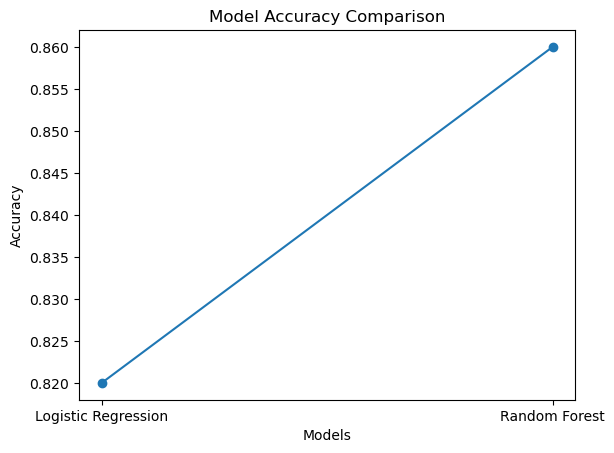

In [24]:
models = ["Logistic Regression", "Random Forest"]
accuracy = [0.82, 0.86]

plt.plot(models, accuracy, marker="o")

plt.title("Model Accuracy Comparison")
plt.xlabel("Models")
plt.ylabel("Accuracy")
plt.show()

Text(95.72222222222221, 0.5, 'Actual')

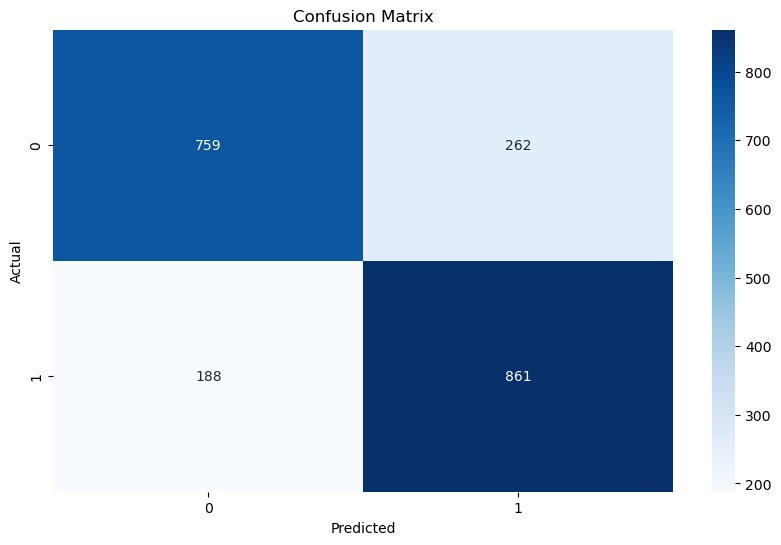

In [27]:
plt.figure(figsize=(10,6))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues")
plt.title("Confusion Matrix")   
plt.xlabel("Predicted")
plt.ylabel("Actual")